In [50]:
from src.api.option_fetcher import OptionFetcher
from src.analysis.volatility_smile import VolatilitySmileAnalyzer
from dotenv import load_dotenv
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
import importlib
import src.api.option_fetcher as option_fetcher
import src.analysis.volatility_smile as volatility_smile

importlib.reload(option_fetcher)
OptionFetcher = option_fetcher.OptionFetcher

importlib.reload(volatility_smile)
VolatilitySmileAnalyzer = volatility_smile.VolatilitySmileAnalyzer

In [52]:
load_dotenv()
api_key = os.getenv("API_KEY")
secret_key = os.getenv("SECRET_KEY")

In [53]:
ticker = "SPY"
expiration_dates = [
    "2026-05-22",
    "2026-05-29",
    "2026-06-05",
    "2026-06-12",
    "2026-06-19",
    "2026-06-26",
    "2026-07-03",
    "2026-07-10",
    "2026-07-17",
    "2026-07-24",
    "2026-07-31",
    "2026-08-21",  # ~3 mois
    "2026-09-18",  # ~4 mois
    "2026-10-16",  # ~5 mois
    "2026-12-18",  # ~7 mois
    "2027-03-19",  # ~10 mois
    "2027-06-18",  # ~13 mois
    "2027-12-17",  # ~19 mois
]
spot_delta = 20

In [54]:
fetcher = OptionFetcher(api_key, secret_key)

In [55]:
spot_price = fetcher.get_spot_price(ticker)
df = fetcher.build_options_df(ticker,expiration_dates,spot_delta,100)
df

,symbol,strike,expiry,type,bid,ask,mid,spread,timestamp
0,SPY260522C00721000,721.0,2026-05-22,call,21.29,21.54,21.415,0.25,2026-05-15 19:05:55.768667+00:00
1,SPY260522C00722000,722.0,2026-05-22,call,20.38,20.86,20.620,0.48,2026-05-15 19:05:55.668673+00:00
2,SPY260522C00723000,723.0,2026-05-22,call,19.58,20.16,19.870,0.58,2026-05-15 19:05:55.671225+00:00
3,SPY260522C00724000,724.0,2026-05-22,call,19.22,19.37,19.295,0.15,2026-05-15 19:05:55.564736+00:00
4,SPY260522C00725000,725.0,2026-05-22,call,17.77,18.33,18.050,0.56,2026-05-15 19:05:53.813755+00:00
...,...,...,...,...,...,...,...,...,...
583,SPY271217P00740000,740.0,2027-12-17,put,55.90,56.12,56.010,0.22,2026-05-15 19:05:56.448159+00:00
584,SPY271217P00745000,745.0,2027-12-17,put,57.67,57.94,57.805,0.27,2026-05-15 19:05:56.393749+00:00
585,SPY271217P00750000,750.0,2027-12-17,put,60.59,60.87,60.730,0.28,2026-05-15 19:05:56.446686+00:00
586,SPY271217P00755000,755.0,2027-12-17,put,62.61,62.88,62.745,0.27,2026-05-15 19:05:56.450474+00:00


In [56]:
smile = VolatilitySmileAnalyzer(df, spot_price, 0.045)
smile_df = smile.build_smile_data()

In [57]:
smile_df

,implied_vol,strike,expiration_date,time_to_expiry
0,0.165146,721.0,2026-05-22,0.018811
1,0.169551,722.0,2026-05-22,0.018811
2,0.174698,723.0,2026-05-22,0.018811
3,0.185505,724.0,2026-05-22,0.018811
4,0.169001,725.0,2026-05-22,0.018811
...,...,...,...,...
583,0.221395,740.0,2027-12-17,1.590337
584,0.220445,745.0,2027-12-17,1.590337
585,0.222611,750.0,2027-12-17,1.590337
586,0.222039,755.0,2027-12-17,1.590337


In [58]:
expiry_date = "2026-05-22"
target = pd.to_datetime(expiry_date).date()
smile_data_2d = smile_df[smile_df["expiration_date"] == target]

In [59]:
smile_data_2d

,implied_vol,strike,expiration_date,time_to_expiry
0,0.165146,721.0,2026-05-22,0.018811
1,0.169551,722.0,2026-05-22,0.018811
2,0.174698,723.0,2026-05-22,0.018811
3,0.185505,724.0,2026-05-22,0.018811
4,0.169001,725.0,2026-05-22,0.018811
...,...,...,...,...
75,0.140372,756.0,2026-05-22,0.018811
76,0.137927,757.0,2026-05-22,0.018811
77,0.133769,758.0,2026-05-22,0.018811
78,0.147540,759.0,2026-05-22,0.018811


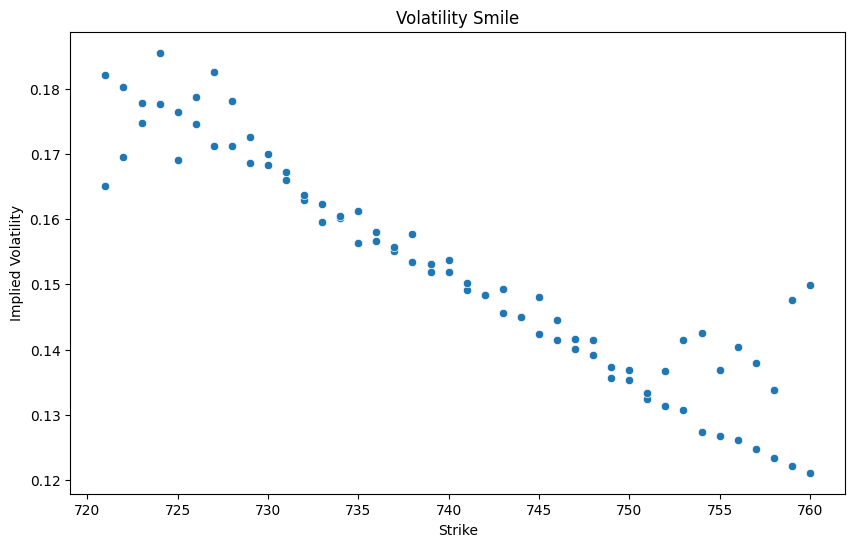

In [60]:
strikes = smile_data_2d["strike"]
implied_vols = smile_data_2d["implied_vol"]
plt.figure(figsize=(10, 6))
sns.scatterplot(x=strikes, y=implied_vols)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.show()

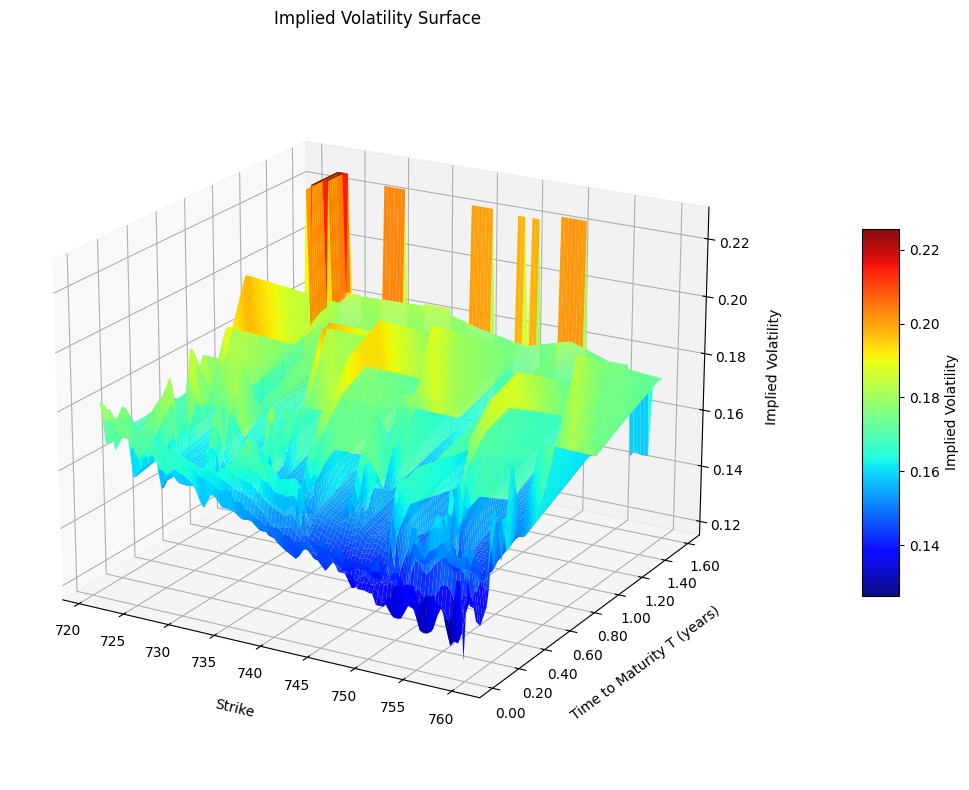

In [61]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

df = smile_df.dropna(subset=['strike', 'implied_vol', 'time_to_expiry']).copy()
df['time_to_expiry'] = df['time_to_expiry'].astype(float)

xi = np.linspace(df['strike'].min(), df['strike'].max(), 100)
yi = np.linspace(df['time_to_expiry'].min(), df['time_to_expiry'].max(), 100)
Xi, Yi = np.meshgrid(xi, yi)

# ✅ Linear uniquement — cubic oscille violemment sur données sparse
Zi = griddata(
    (df['strike'].values, df['time_to_expiry'].values),
    df['implied_vol'].values,
    (Xi, Yi),
    method='linear'
)

# ✅ Nearest pour les NaN aux bords
nan_mask = np.isnan(Zi)
if nan_mask.any():
    Zi_nearest = griddata(
        (df['strike'].values, df['time_to_expiry'].values),
        df['implied_vol'].values,
        (Xi, Yi), method='nearest'
    )
    Zi[nan_mask] = Zi_nearest[nan_mask]

# ✅ Clip AVANT plot_surface
vol_min, vol_max = df['implied_vol'].min(), df['implied_vol'].max()
Zi = np.clip(Zi, vol_min, vol_max)

# --- Plot ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    Xi, Yi, Zi,
    cmap='jet',
    edgecolor='none',
    antialiased=True,
    rcount=150,
    ccount=150,
    alpha=0.95
)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1, label='Implied Volatility')

# Zlim serré autour des vraies valeurs de vol
zp = 0.05 * (vol_max - vol_min)
ax.set_zlim(max(0.0, vol_min - zp), vol_max + zp)

ax.view_init(elev=20, azim=-60)
ax.set_xlabel('Strike', labelpad=12)
ax.set_ylabel('Time to Maturity T (years)', labelpad=12)
ax.set_zlabel('Implied Volatility', labelpad=10)
ax.set_title('Implied Volatility Surface', pad=15)

# Ticks Y lisibles sans notation scientifique
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.show()